In [ ]:
## Day 13 - Comparing ML Models

What I learned today:
- Tested 5 models on same Titanic data
- Single test: Logistic Regression tied Random Forest at 81%
- CV revealed Random Forest is true winner at 81.38%
- Logistic Regression most consistent ±1.69%
- SVC and KNeighbors struggled due to feature scaling
- Always use CV for honest model comparison
- Never assume one model always wins

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# Our 5 models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Load and clean
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop("Cabin", axis=1)
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

X = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ready!")
print("Training samples:", len(X_train))
print("Testing samples: ", len(X_test))

Ready!
Training samples: 712
Testing samples:  179


In [2]:
# Define all 5 models
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(random_state=42),
    "KNeighbors"          : KNeighborsClassifier(),
    "SVC"                 : SVC(random_state=42)
}

# Test each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    results[name] = accuracy
    print(f"{name:25} → {accuracy*100:.2f}%")

Logistic Regression       → 81.01%
Decision Tree             → 75.42%
Random Forest             → 81.01%
KNeighbors                → 69.83%
SVC                       → 65.36%


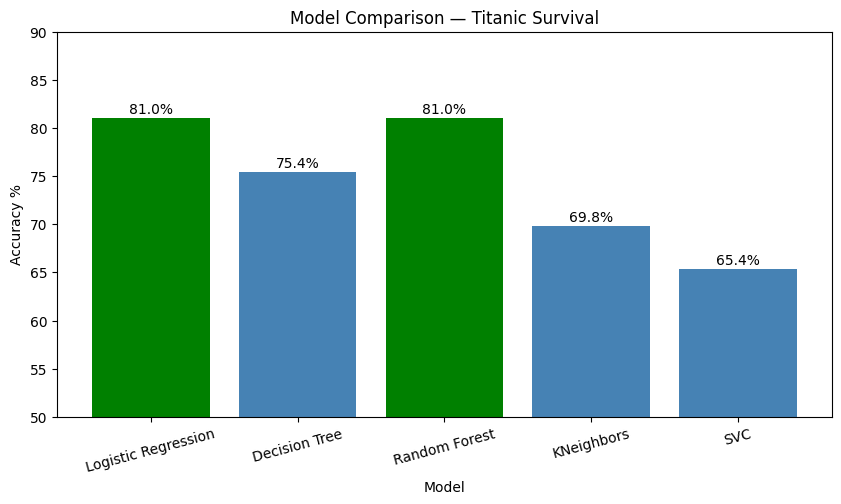

In [4]:
# Plot model comparison
names = list(models.keys())
scores = [accuracy_score(y_test, m.predict(X_test)) * 100 
          for m in models.values()]

plt.figure(figsize=(10, 5))
plt.bar(names, scores, color=['green' if v == max(results.values()) 
               else 'steelblue' for v in results.values()])
plt.title("Model Comparison — Titanic Survival")
plt.xlabel("Model")
plt.ylabel("Accuracy %")
plt.ylim(50, 90)
plt.xticks(rotation=15)
for i, score in enumerate(scores):
    plt.text(i, score + 0.5, f"{score:.1f}%", ha="center")
plt.show()

In [5]:
print("Cross Validation Results (5 fold):")
print("=" * 45)

cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5)
    cv_results[name] = cv_scores.mean()
    print(f"{name:25} → {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

Cross Validation Results (5 fold):
Logistic Regression       → 78.45% ± 1.69%
Decision Tree             → 77.11% ± 3.86%
Random Forest             → 81.38% ± 4.11%
KNeighbors                → 69.82% ± 3.60%
SVC                       → 67.46% ± 4.23%


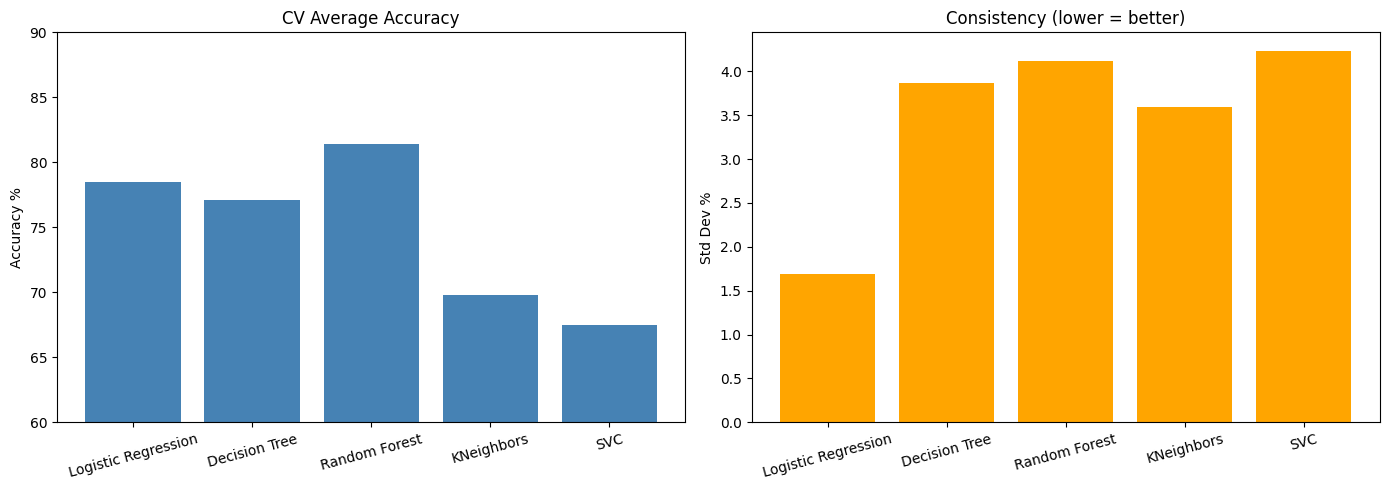

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names = list(cv_results.keys())
means = [v*100 for v in cv_results.values()]
stds  = [cross_val_score(m, X, y, cv=5).std()*100 
         for m in models.values()]

# Chart 1 — Average accuracy
ax1.bar(names, means, color='steelblue')
ax1.set_title('CV Average Accuracy')
ax1.set_ylabel('Accuracy %')
ax1.set_ylim([60, 90])
ax1.tick_params(axis='x', rotation=15)

# Chart 2 — Consistency (lower std = better)
ax2.bar(names, stds, color='orange')
ax2.set_title('Consistency (lower = better)')
ax2.set_ylabel('Std Dev %')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()